#Redes Neurais Convolucionais

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import patches
import numpy as np

import torch, torchvision
from torchvision import datasets, transforms

##Classificação

In [ ]:
MNIST = torchvision.datasets.MNIST('.',
                                   train = False,
                                   transform = transforms.ToTensor(),
                                   download = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.96MB/s]


In [ ]:
dado, rotulo = MNIST[0]
print(dado.shape, rotulo)
print(type(dado), type(rotulo))
print(dado.size(), rotulo)

torch.Size([1, 28, 28]) 7
<class 'torch.Tensor'> <class 'int'>
torch.Size([1, 28, 28]) 7


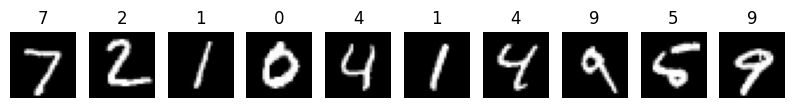

In [ ]:
fig, axs = plt.subplots(1, 10, figsize = (10, 10))
for i in range(10):
  dado, rotulo = MNIST[i]
  axs[i].imshow(dado.squeeze(), cmap = 'gray')
  axs[i].set_title(rotulo)
  axs[i].axis('off')

##Detecção

In [ ]:
VOC= torchvision.datasets.VOCDetection('.',
                                      image_set = 'train',
                                      download = True,
                                      transform = transforms.ToTensor()
                                      )

URLError: <urlopen error [Errno 110] Connection timed out>

In [ ]:
dado, rotulo = VOC[0]
print(dado.shape)
print(type(dado), type(rotulo))
print(dado.size())
dado = dado.permute(1,2,0) #muda posição das dimensões
dado.shape
plt.imshow(dado)

In [ ]:
rotulo

In [ ]:
bbox = rotulo['annotation']['object'][0]['bndbox']
xmax = int(bbox['xmax'])
xmin = int(bbox['xmin'])
ymax = int(bbox['ymax'])
ymin = int(bbox['ymin'])

fig, ax = plt.subplots(figsize=(8, 7))
plt.imshow(dado)

rect = patches.Rectangle((xmin, ymin), xmax-xmin , ymax-ymin, fill=False, linewidth=5, edgecolor='r')
ax.add_patch(rect)

plt.show()

##Segmentação

In [ ]:
coco = datasets.VOCSegmentation('./',
                             image_set='train',
                             download=True,
                             transform=transforms.ToTensor(),
                             target_transform=transforms.ToTensor())

dado, rotulo = coco[0]
print(type(dado), type(rotulo))
print(dado.size(), rotulo.size())


URLError: <urlopen error [Errno 110] Connection timed out>

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(10, 10))
dado = dado.permute(1, 2, 0)

axs[0].imshow(dado)
axs[1].imshow(rotulo[0], cmap='gray')

In [ ]:
data = datasets.CIFAR10('./',
                      train=False,
                      download=True,
                      transform=transforms.ToTensor())


dado, rotulo = data[0]
print(type(dado), type(rotulo))

# Channel First: Padrão do torch
print(dado.size()) # C x H x W

fig, axs = plt.subplots(1,26, figsize=(28, 4))

for i in range(26):
  dado, rotulo = data[i]
  # Lembre-se que imagens são carregadas na dimensão C x H x W
  # é preciso permutar as dimensões para plot.
  axs[i].imshow(dado.permute(1,2,0))
  axs[i].set_title(str(rotulo))

plt.show()

#Convolução 1D

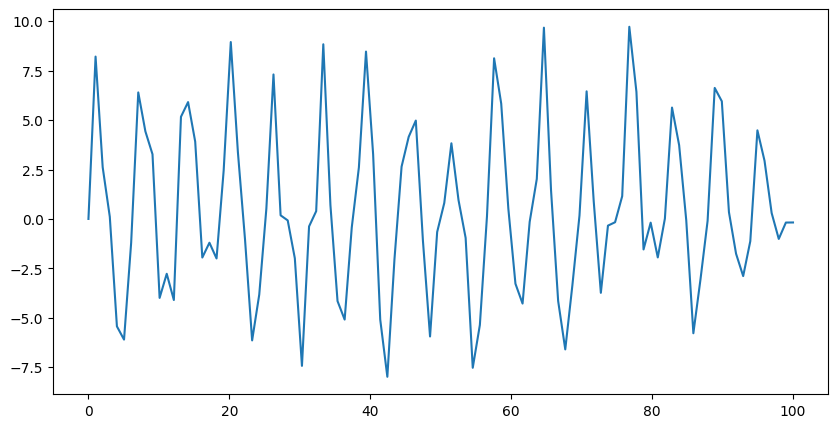

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve

x = np.linspace(0, 100, 100)
y = 10 * np.sin(x) * np.random.rand(x.shape[0])

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.show()

A célula a seguir apresenta uma função que usa o matplotlib para imprimir os sinais 1D como imagens.

In [ ]:
def show(valores, title,):
  plt.figure(figsize=(len(valores),2))
  plt.imshow(valores[np.newaxis, :], cmap = 'gray')
  for k, s in enumerate(valores):
    plt.text(k, 0, '{:.1f}'.format(s), fontsize = 16, color = 'red', ha = 'center', va = 'center')
  plt.title(title, fontsize = 18)
  plt.yticks([])

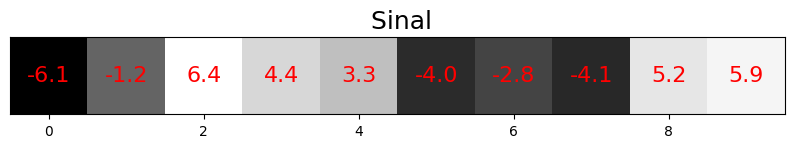

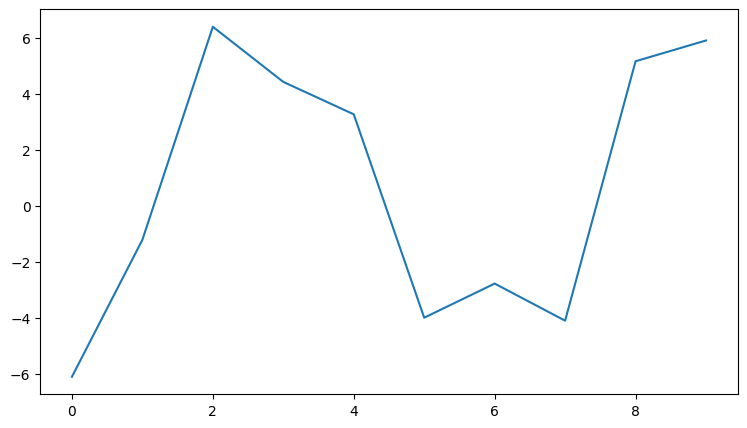

In [ ]:
sinal = y[5:15]
show(sinal, ' Sinal')
plt.figure(figsize=(9,5))
plt.plot(sinal)

##Kernel



No contexto de processamento de imagens, o kernel é um **filtro convolucional**. De forma prática, é uma matriz n-dimensional que será operada com o dado através de uma convolução.

Pode-se dizer que a convolução **mede a semelhança** entre os dois sinais.

Precisamos portanto propor um kernel que simule o padrão procurado: intervalos crescentes.
> Mas lembre-se que a convolução opera as funções após **inverter o kernel**.

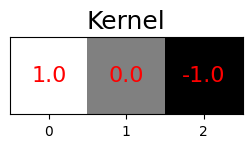

In [ ]:
kernel = np.asarray([1, 0, -1])
show(kernel, 'Kernel')

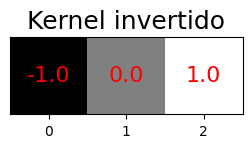

In [ ]:
#kernel invertido
kernel_invertido = np.flip(kernel)
show(kernel_invertido, 'Kernel invertido')

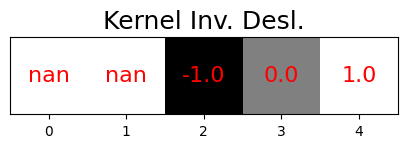

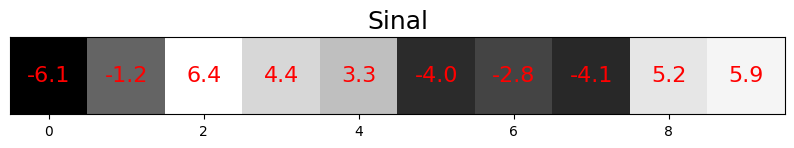

In [ ]:
plt.close('all')

## Vamos alterar o valor de u
## para deslocar o kernel
u=2
deslocamento = [float('nan')] * u
kernel_deslocado = np.hstack( (deslocamento, kernel_invertido) )

show(kernel_deslocado, 'Kernel Inv. Desl.')
show(sinal, 'Sinal')

Serve só pra mostrar a soma da convolução e sopreposição ao longo do sinal

In [ ]:
ativacao = convolve(sinal, kernel, mode = 'valid')

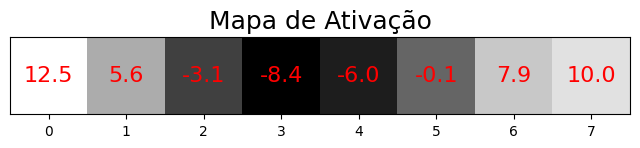

In [ ]:
show(ativacao, 'Mapa de Ativação')

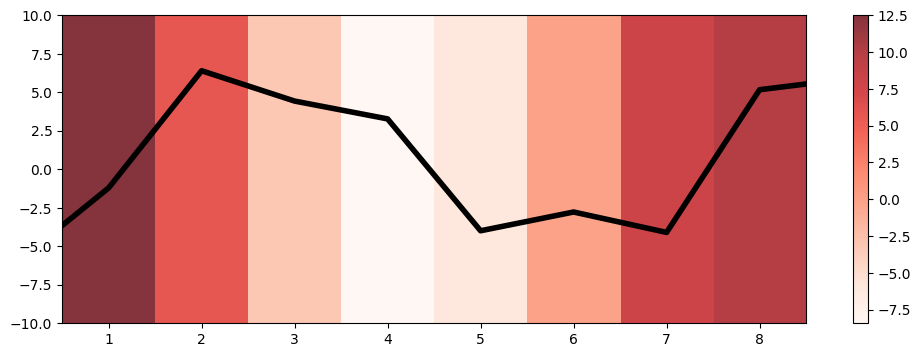

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sinal, color='k', linewidth=4)
plt.imshow(ativacao[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.8, extent=(0.5, 8.5, -10, 10))
plt.colorbar();

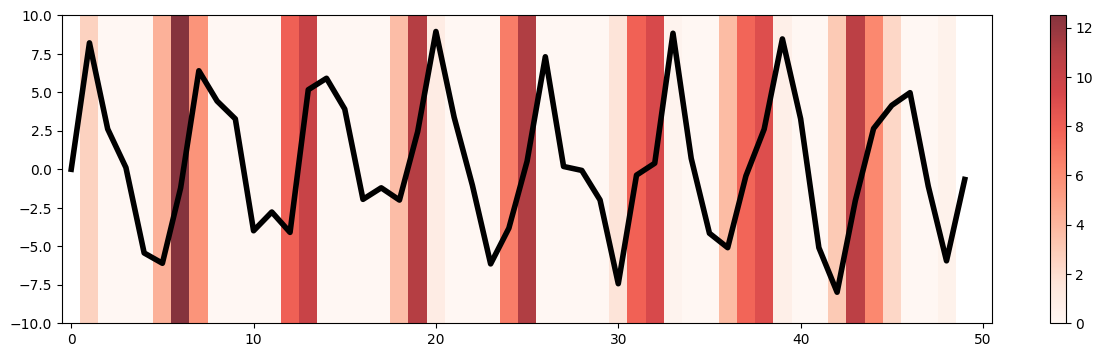

In [ ]:
out = convolve(y[:50], kernel, mode='valid')
out[out < 0] = 0

plt.figure(figsize=(15, 4))
plt.plot(y[:50], color='k', linewidth=4)
plt.imshow(out[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.8, extent=(0.5, 48.5, -10, 10))
plt.xlim(-0.5, 50.5)
plt.colorbar()

##Convolução 2D

In [ ]:
from skimage import io, color, transform, data
from scipy.signal import convolve
import matplotlib.pyplot as plt
import numpy as np

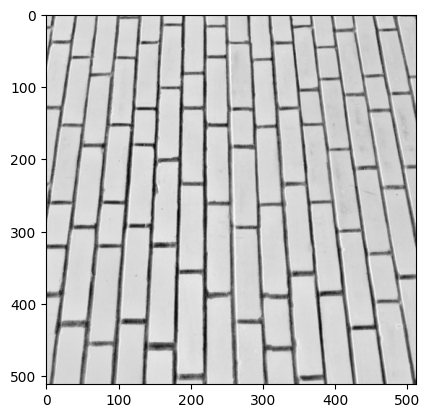

In [ ]:
img = data.brick()
plt.imshow(img, cmap='Greys')

Para nos auxiliar daqui pra frente, vamos definir um método para imprimir os kernels como imagens.

In [ ]:
def show(valores, title):
  plt.figure(figsize=(len(valores), len(valores) ))
  plt.imshow(valores, cmap='gray')
  for i, line in enumerate(valores):
    for j, col in enumerate(line):
      plt.text(j, i, '{:.0f}'.format(col), fontsize=16, color='red', ha='center', va='center')
  plt.title(title)
  plt.xticks([])
  plt.yticks([])
  plt.savefig(title+'.png', format='png', dpi=100, bbox_inches='tight')

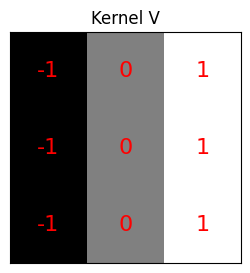

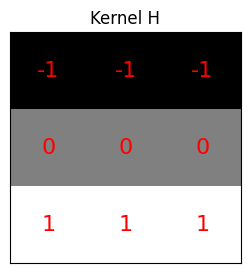

In [ ]:
kernel_v = [[-1, 0, 1],
            [-1, 0, 1],
            [-1, 0, 1],]
show(kernel_v, 'Kernel V')

kernel_h = [[-1,-1,-1],
            [0,0,0],
            [1,1,1]]

show(kernel_h, 'Kernel H')

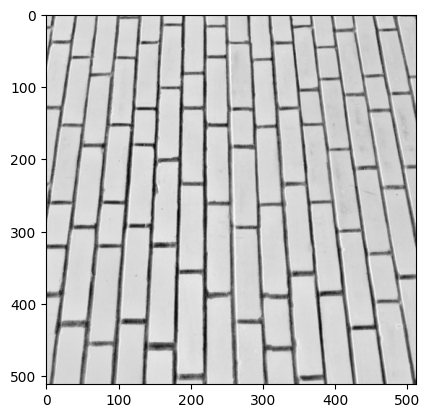

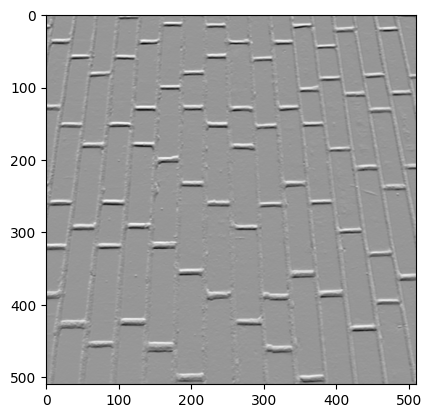

In [ ]:
mapa_de_caract = convolve(img, kernel_h , mode= 'valid')
plt.imshow(img, cmap= 'Greys')
plt.figure()
plt.imshow(mapa_de_caract, cmap='Greys')

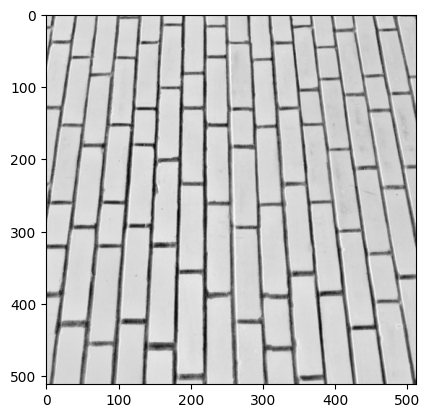

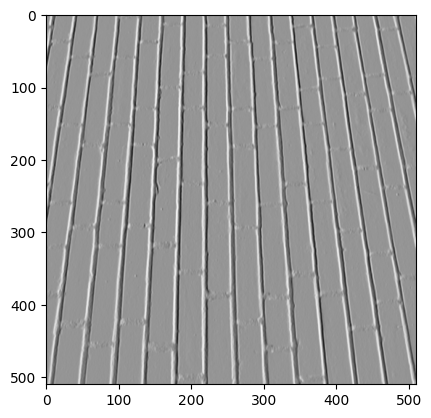

In [ ]:
mapa_de_caract = convolve(img, kernel_v , mode= 'valid')
plt.imshow(img, cmap= 'Greys')
plt.figure()
plt.imshow(mapa_de_caract, cmap='Greys')

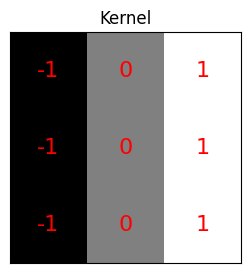

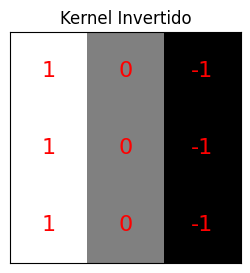

In [ ]:
show(kernel_v, 'Kernel')
show(np.flip(kernel_v), 'Kernel Invertido')

In [ ]:
!wget https://is5-ssl.mzstatic.com/image/thumb/Purple113/v4/a2/56/30/a2563080-dddc-6a02-9034-a461c6c02fae/AppIcon-0-1x_U007emarketing-0-0-85-220-0-10.png/1200x630wa.png

--2025-07-30 20:31:49--  https://is5-ssl.mzstatic.com/image/thumb/Purple113/v4/a2/56/30/a2563080-dddc-6a02-9034-a461c6c02fae/AppIcon-0-1x_U007emarketing-0-0-85-220-0-10.png/1200x630wa.png
Resolving is5-ssl.mzstatic.com (is5-ssl.mzstatic.com)... 151.101.3.6, 151.101.67.6, 151.101.131.6, ...
Connecting to is5-ssl.mzstatic.com (is5-ssl.mzstatic.com)|151.101.3.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30426 (30K) [image/png]
Saving to: ‘1200x630wa.png’

1200x630wa.png      100%[===================>]  29.71K  --.-KB/s    in 0.007s  

2025-07-30 20:31:49 (4.26 MB/s) - ‘1200x630wa.png’ saved [30426/30426]



Text(0.5, 1.0, 'Mapa de ativação')

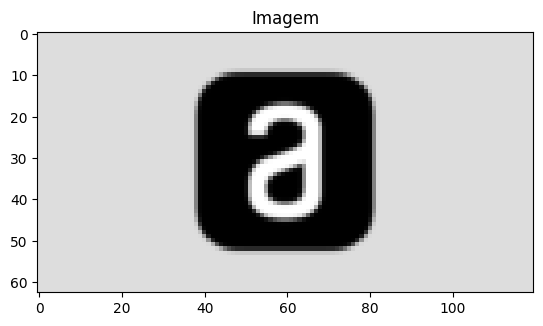

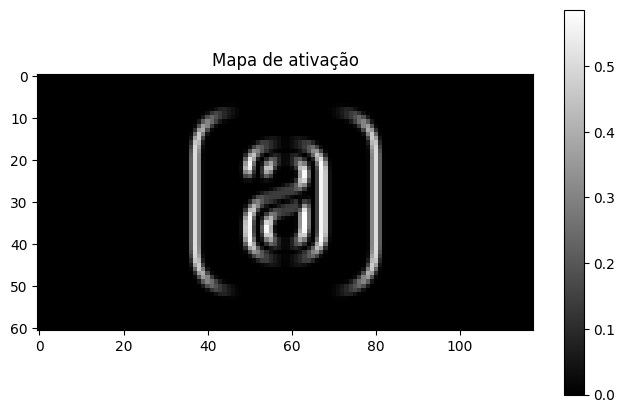

In [ ]:
img = io.imread('1200x630wa.png')
img = color.rgba2rgb(img)
img = color.rgb2gray(img)
img = transform.resize(img, (img.shape[0]//10, img.shape[1]//10) )

saida = convolve(img, kernel_v, 'valid')

plt.imshow(img, cmap='gray')
plt.title('Imagem')

plt.figure(figsize=(8, 5))
plt.imshow(np.abs(saida), cmap='gray')
plt.colorbar()
plt.title('Mapa de ativação')

#Filtros Convolucionais



Retomando o que já aprendemos
* **Kernels** são filtros convolucionais. Na prática são arrays n-dimensionais que são operados com o dado através da convolução.
* Os **pesos do kernel**, ou seja, os elementos do array, carregam o padrão que será procurado no dado original.

Esses filtros podem ser manualmente projetados se já sabemos o padrão que queremos procurar, ou o mapa de ativação desejado. A seguir vamos conhecer alguns kernels convolucionais e a intuição por trás do padrão que eles projetam.

In [ ]:
import matplotlib.pyplot as plt
from skimage import io

from scipy.signal import convolve
import numpy as np

%matplotlib inline

In [ ]:
def show(img, kernel, resultado, titulo):
  fig, axs = plt.subplots(1, 3, figsize=(15, 5))
  plot = [img, kernel, resultado]
  titulos = ['Imagem', titulo, 'Mapa de Ativação']
  for k, ax in enumerate(axs):
    ax.imshow(plot[k], cmap='gray')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(titulos[k])

  for i, line in enumerate(kernel):
    for j, col in enumerate(line):
      axs[1].text(j, i, '{:.2f}'.format(col), fontsize=12, color='red', ha='center', va='center')

In [ ]:
!wget https://s3.us-east-1.amazonaws.com/jarvis-caelum/GUI.jpg

--2025-07-30 21:43:44--  https://s3.us-east-1.amazonaws.com/jarvis-caelum/GUI.jpg
Resolving s3.us-east-1.amazonaws.com (s3.us-east-1.amazonaws.com)... 52.217.235.112, 52.217.131.224, 52.217.196.240, ...
Connecting to s3.us-east-1.amazonaws.com (s3.us-east-1.amazonaws.com)|52.217.235.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82709 (81K) [image/jpeg]
Saving to: ‘GUI.jpg.1’

GUI.jpg.1           100%[===================>]  80.77K  --.-KB/s    in 0.1s    

2025-07-30 21:43:45 (659 KB/s) - ‘GUI.jpg.1’ saved [82709/82709]



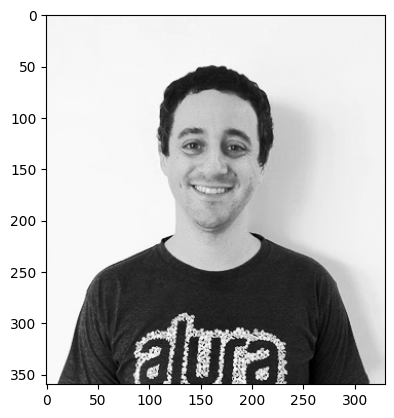

In [ ]:
img = io.imread('GUI.jpg')
img = img[:,:,0]
plt.imshow(img, cmap='gray')

## Filtro da Média

Ao aplicar este filtro a uma imagem, o mapa de ativação resultante será uma versão suavizada da imagem original (mais "borrada", menos nítida). Este efeito é alcançado explorando a operação de convolução para **tirar a média dos pixels** de subregiões da imagem.

Os pesos desse kernel são definidos para replicar a operação da média, ou seja, para um filtro $3 \times 3$ com 9 pesos, temos que: <br><br>
\begin{equation}
\frac{\sum_{x=1}^{9} p(x)}{9} = \sum_{x=1}^{9} \frac{1}{9} p(x)
\end{equation}

Vamos modelar dois filtros:
* $3 \times 3$, com todos os pesos iguais a $\frac{1}{3^2}$

* $9 \times 9$, com todos os pesos iguais a $\frac{1}{9^2}$

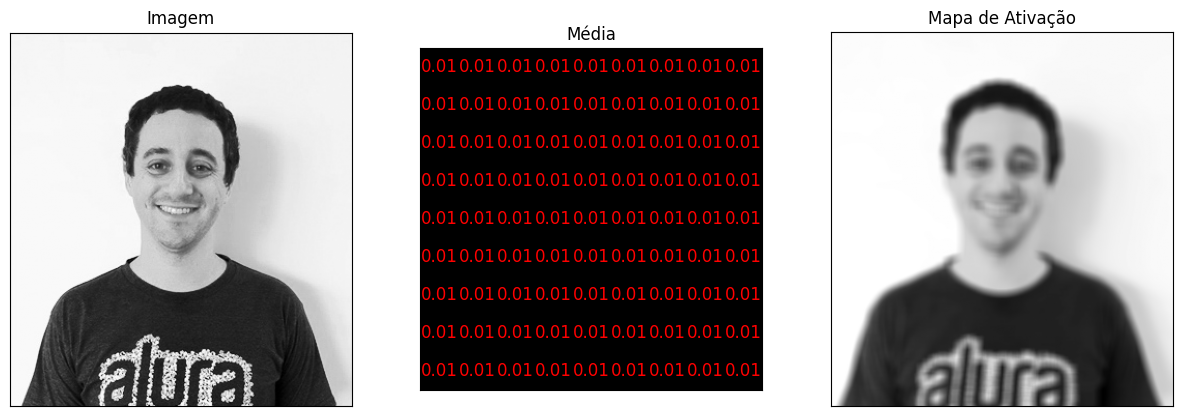

In [ ]:
kernel_media = np.zeros((9,9))
kernel_media[:]= 1.0/ (9**2)
kernel_media
resultado = convolve(img, kernel_media, mode='valid')
show(img, kernel_media, resultado, 'Média')

## Sobel

Esse se parece muito com o filtro de bordas que já fizemos na aula passada, com a diferença que os vizinhos diretos do pixel central tem valor absoluto de maior intensidade (na horizontal ou na vertical, a depender da borda desejada).

> Após realizar a convolução, podemos imprimir os **valores absolutos** do mapa de ativação para visualizar as bordas independente do sinal da ativação.


In [ ]:
sobel_v = np.zeros((3,3))
sobel_v[:, 0] = -1
sobel_v[:, 2] = 1
sobel_v[1, [0,2]] = [-2, 2]
sobel_v


array([[-1.,  0.,  1.],
       [-2.,  0.,  2.],
       [-1.,  0.,  1.]])

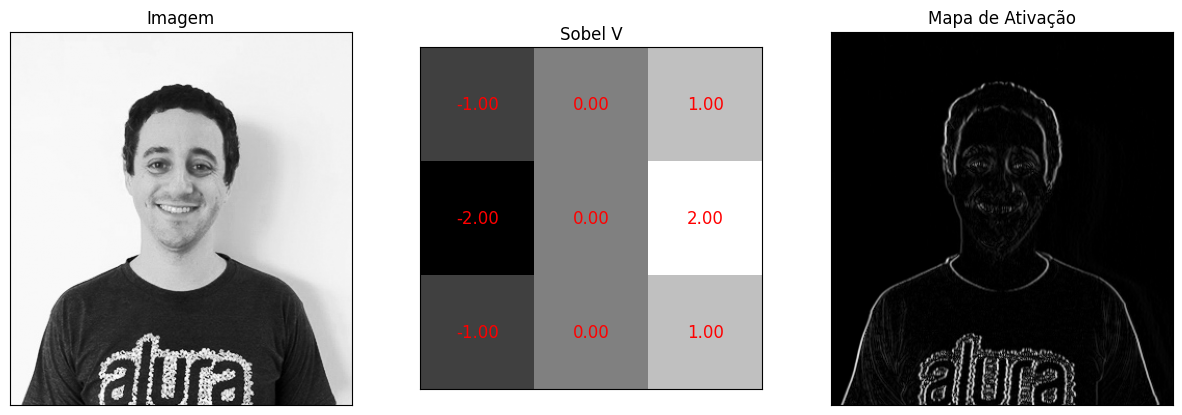

In [ ]:
resultado = convolve(img, sobel_v, mode='valid')
show(img, sobel_v, np.abs(resultado), 'Sobel V')

[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


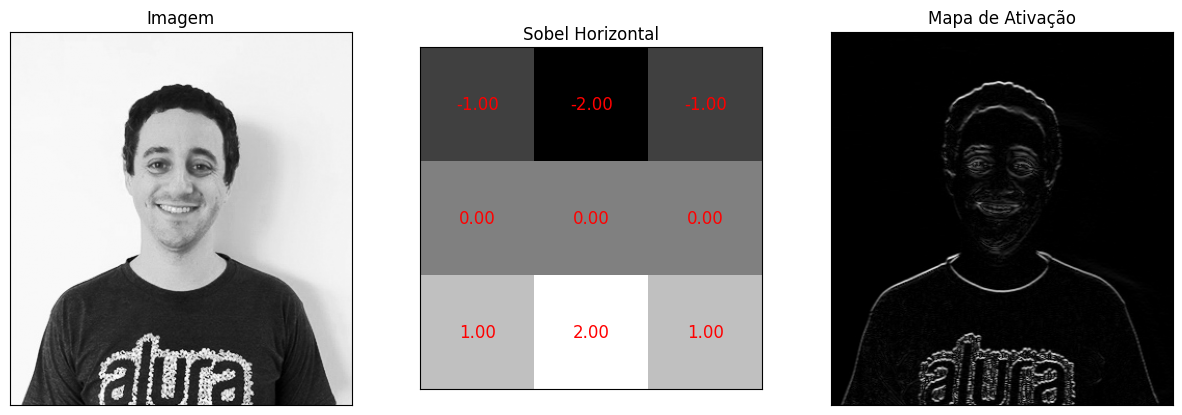

In [ ]:
##### SOBEL HORIZONTAL
sobel_h = np.zeros((3,3))
sobel_h[0, :] = -1
sobel_h[2, :] = 1
sobel_h[[0, 2], 1] = [-2, 2]
print(sobel_h)

resultado = convolve(img, sobel_h, mode='valid')
show(img, sobel_h, np.abs(resultado), 'Sobel Horizontal')


## Laplace

Por fim, vamos ver mais um filtro utilizado para detecção de bordas, o Laplace. Diferente do Sobel, este filtro destaca igualmente bordas de diferentes direções.

In [ ]:
laplace = np.ones((3,3)) * -1
laplace[1,1] = 8
laplace

array([[-1., -1., -1.],
       [-1.,  8., -1.],
       [-1., -1., -1.]])

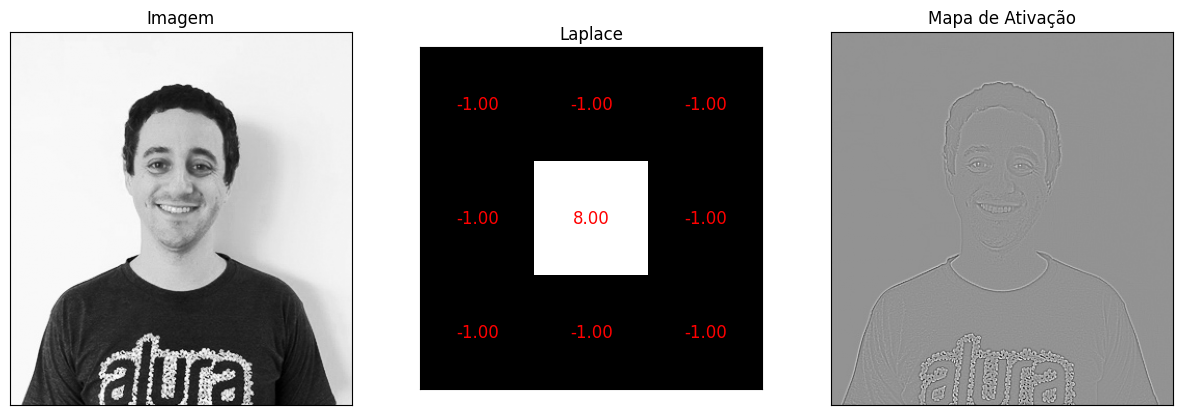

In [ ]:
resultado = convolve(img, laplace, mode='valid')
show(img, laplace, --resultado, 'Laplace')

# Convolução e Padrões Complexos

Para entender melhor como a convolução funciona como um casamento de padrões, vamos agora definir um filtro convolucional mais complexo, mas capaz de encontrar um casamento perfeito no dado.

Primeiro vamos baixar a imagem que será usada de exemplo:

In [ ]:
!wget https://www.dropbox.com/s/0nrix9eknyybuqk/image_2007_000032.jpg?dl=0
!mv image_2007_000032.jpg?dl=0 plane.jpg

--2025-07-30 21:59:23--  https://www.dropbox.com/s/0nrix9eknyybuqk/image_2007_000032.jpg?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/4bkbp9cta3rjw3qniyla3/image_2007_000032.jpg?rlkey=1d75pv8h17uzw8gyag4o67ksq&dl=0 [following]
--2025-07-30 21:59:24--  https://www.dropbox.com/scl/fi/4bkbp9cta3rjw3qniyla3/image_2007_000032.jpg?rlkey=1d75pv8h17uzw8gyag4o67ksq&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5d27fc4489dd9322d2864f0f62.dl.dropboxusercontent.com/cd/0/inline/Cud-H8iFzDY0oUEtvfeXOYyhRC0Jx7WBG3KIfjapzU_uLO3TQwck8XMyeIhiAqbhC-t8YAuM9Le4cxLoUN-rCMfgj7moXQdqazbhgH5w9cSGHL0_TruNKz7-2EgGlGCSnPA/file# [following]
--2025-07-30 21:59:24--  https://uc5d27fc4489dd9322d2864f0f62.dl.dropboxusercont

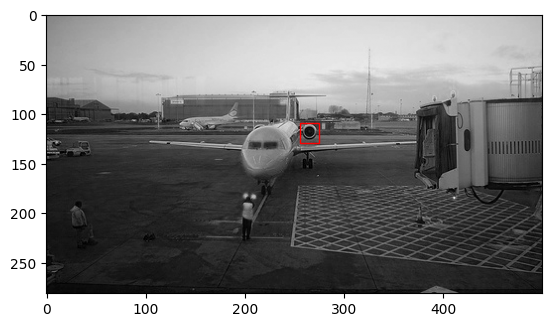

In [ ]:
import matplotlib.patches as patches

# Imprime imagem e seleciona retangulo
img = io.imread('plane.jpg')
img = img[:,:,0]
retangulo = [109, 129, 255, 275]


# # Imprime imagem e retangulo
fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
ax.add_patch(patches.Rectangle((retangulo[2], retangulo[0]),
                               (retangulo[3] - retangulo[2]),
                               (retangulo[1] - retangulo[0]), color='red', fill=False))

Para que o patch possa ser utilizado como filtro de convolução, precisamos:
* Subtrair o patch pelo valor do pixel médio (centralizando a distribuição)
* Inverter o filtro com a função ```flip``` do numpy.

In [ ]:
retangulo[0], retangulo[1], retangulo[2], retangulo[3]

(109, 129, 255, 275)

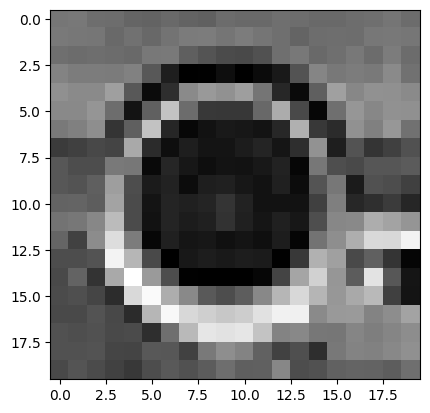

In [ ]:
patch = img[retangulo[0]:retangulo[1], retangulo[2]:retangulo[3]]
patch = patch - patch.mean()
kernel = np.flip(np.flip(patch, axis=0), axis=1)
plt.imshow(kernel, cmap='gray')

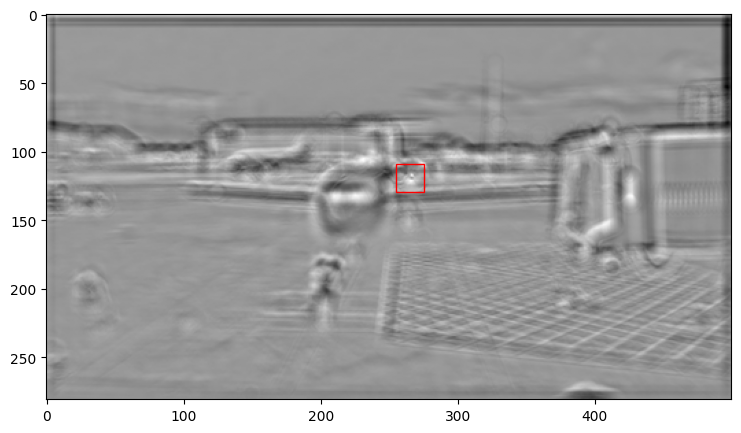

In [ ]:
resultado = convolve(img, patch, mode='same')

fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(resultado, cmap='gray')
ax.add_patch(patches.Rectangle((retangulo[2], retangulo[0]),
                               (retangulo[3] - retangulo[2]),
                               (retangulo[1] - retangulo[0]), color='red', fill=False))

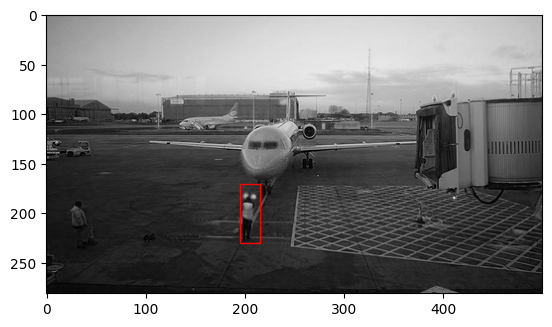

In [ ]:
import matplotlib.patches as patches

# Imprime imagem e seleciona boundaries
img = io.imread('plane.jpg')
img = img[:,:,0]
boundaries = [170, 230, 195, 215]


# # Imprime imagem e boundaries
fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
ax.add_patch(patches.Rectangle((boundaries[2], boundaries[0]),
                               (boundaries[3] - boundaries[2]),
                               (boundaries[1] - boundaries[0]), color='red', fill=False))

#Implementando no Pytorch


In [ ]:
import torch
from torch import nn

from skimage import data
import matplotlib.pyplot as plt



Documentação: https://pytorch.org/docs/stable/nn.html#torch.nn.Conv2d

Começando pela operação principal, a convolução está contida na camada ```nn.Conv2d```. Dentre os parâmetros que ela recebe, vamos focar nos que já conhecemos, que já são suficientes para uma diversa gama de aplicações.

```python
torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
```

**```in_channels```**<br>
Assim como toda camada, seu primeiro parâmetro é referente ao **tamanho da entrada**. Não é necessário explicitar as 2 primeiras dimensões da entrada, apenas a profundidade, que corresponde à **quantidade de canais**.

**```out_channels```** <br>
Independentemente do número de canais de entrada, um único filtro convolucional terá como resultado um canal de saída. Alterando esse parâmetro estamos na verdade definindo o **número de filtros** que irão compor essa camada, interferindo na quantidade de neurônios dessa camada.

> Dica: Nas arquiteturas de redes neurais mais populares, aumentamos a dimensão do canal à medida que avançamos na rede neural, geralmente diminuindo a resolução.

**```kernel_size```** <br>
Tamanho dos filtros convolucionais. Pode ser uma tupla ou um único número. Ex: ```kernel_size = 3``` criará filtros $3 \times 3$

**```stride```** <br>
Controla o pulo da convolução ao longo da imagem.

**```padding```** <br>
Preenchimento com zeros nas bordas da imagem.

(512, 512) (512, 512, 3)


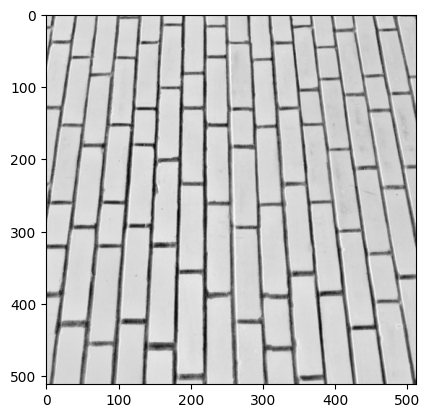

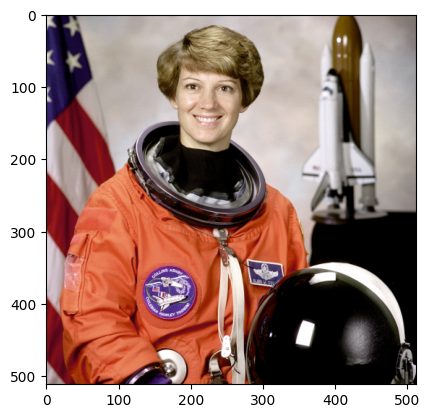

In [ ]:
pb = data.brick()
rgb = data.astronaut()

print(pb.shape, rgb.shape)

plt.imshow(pb, cmap='Greys')
plt.figure()
plt.imshow(rgb)

Na célula a seguir vamos definir uma camada convolucional para realizar o forward na figura *brick*. Para isso, preste atenção em alguns detalhes:

* A entrada deve ser um dado tipo Tensor.
* A camada Convolucional espera uma entrada com as seguintes dimensões:
 $B \times C \times H \times W$

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16,
                 kernel_size=3, padding = 1)
print(conv)

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [ ]:
pb_tns = torch.Tensor(pb)
pb_tns = pb_tns.view(1,1, pb_tns.size(0), pb_tns.size(1))
print(pb_tns.size())

mapa_de_ativacao = conv(pb_tns)
print(mapa_de_ativacao.size()) #perdeu resolução se n colocar padding = 1

torch.Size([1, 1, 512, 512])
torch.Size([1, 16, 512, 512])


In [ ]:
conv = nn.Conv2d(in_channels=3, out_channels=16,
                 kernel_size=5, padding=2)

print(conv)
rgb_tns = torch.Tensor(rgb)
rgb_tns = rgb_tns.permute(2, 0, 1).unsqueeze(0)
print(rgb_tns.size())

mapa_de_ativacao = conv(rgb_tns)
print(mapa_de_ativacao.size())

Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
torch.Size([1, 3, 512, 512])
torch.Size([1, 16, 512, 512])


##Pooling

Documentação: https://pytorch.org/docs/stable/nn.html#torch.nn.MaxPool2d

```python
torch.nn.MaxPool2d(kernel_size, stride=None, padding=0)
```

**```kernel_size```** <br>
Tamanho dos *Field of View*. Pode ser uma tupla ou um único número. Ex: ```kernel_size = 3``` definirá FoV de $3 \times 3$

**```stride```** <br>
Controla o pulo da janela deslizante.

**```padding```** <br>
Preenchimento com zeros nas bordas da imagem.

A camda de pooling espera uma entrada de **pelo menos** 3 dimensões ($C \times H \times W$), mas em geral a rede irá prover também a dimensão do batch ($B \times C \times H \times W$)

In [ ]:
tns = torch.FloatTensor ([ [ [1,2,3],
                             [4,5,6],
                             [7,8,9] ] ])
pool = nn.MaxPool2d(kernel_size = 2, stride = 1)
saida = pool(tns)
print(tns.size())
print(tns)
print(saida.size())
print(saida)


torch.Size([1, 3, 3])
tensor([[[1., 2., 3.],
         [4., 5., 6.],
         [7., 8., 9.]]])
torch.Size([1, 2, 2])
tensor([[[5., 6.],
         [8., 9.]]])


In [ ]:
conv = nn.Conv2d(in_channels=3, out_channels=16,
                 kernel_size=3, padding=1)

rgb = data.astronaut()
rgb_tns = torch.Tensor(rgb)
rgb_tns = rgb_tns.permute(2, 0, 1).unsqueeze(0)
mapa_de_ativacao = conv(rgb_tns)
print('Feature Map:', mapa_de_ativacao.shape)

Feature Map: torch.Size([1, 16, 512, 512])


In [ ]:
pool = nn.MaxPool2d(kernel_size = 2)
saida = pool(mapa_de_ativacao)
print(saida.size())

torch.Size([1, 16, 256, 256])


## Batch Normalization

Documentação: https://pytorch.org/docs/stable/nn.html#torch.nn.BatchNorm2d

```python
torch.nn.BatchNorm2d(num_features)
```

**```num_features```**<br>
$\mathbf{\gamma}$ e $\mathbf{\beta}$ são aprendidos individualmente para cada canal da entrada. Em ativações de camadas intermediárias, esse valor corresponde ao **número de feature maps**.


In [ ]:
blococonv = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding = 1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 10)

)
print(blococonv)
minibatch = torch.cat(12*[rgb_tns])
print(minibatch.size())
saida = blococonv(minibatch)
print(saida.size())

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=10, stride=10, padding=0, dilation=1, ceil_mode=False)
)
torch.Size([12, 3, 512, 512])
torch.Size([12, 32, 51, 51])


# Carregamento de Dados

Usaremos o dataset [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html), um conjunto de imagens RGB divididas em 10 categorias de objeto: avião, automóvel, pássaro, gato, veado, cachorro, sapo, cavalo, navio, caminhão. As imagens possuem $32 \times 32$ pixels.

Trata-se de um dataset de 60 mil imagens naturais (do mundo real), muito utilizado para avaliar a qualidade de modelos de aprendizado profundo.

https://pytorch.org/docs/stable/torchvision/datasets.html#cifar

In [1]:
# Implementação e treinamento da rede

import torch
from torch import nn, optim

# Carregamento de Dados e Modelos
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision import transforms

# Plots e análises
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import time, os

data_transform = transforms.Compose([
                                     transforms.Resize(32),
                                     transforms.ToTensor(),])

train_set = datasets.CIFAR10('.',
                      train=True,
                      transform=data_transform,
                      download=True)

test_set = datasets.CIFAR10('.',
                      train=False,
                      transform=data_transform,
                      download=False)

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


In [2]:


%matplotlib inline

# Configurando hiperparâmetros.
args = {
    'epoch_num': 5,      # Número de épocas.
    'lr': 1e-3,           # Taxa de aprendizado.
    'weight_decay': 8e-4, # Penalidade L2 (Regularização).
    'batch_size': 20,     # Tamanho do batch.
}

# Definindo dispositivo de hardware
if torch.cuda.is_available():
    args['device'] = torch.device('cuda')
else:
    args['device'] = torch.device('cpu')

print(args['device'])

cuda


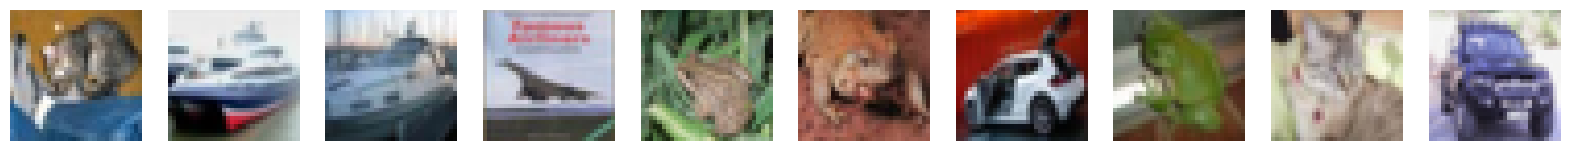

In [3]:
fig, axs = plt.subplots(1,10, figsize=(20, 2))
for i in range(10):
  data, label = test_set[i]
  axs[i].imshow(data.permute((1,2,0)))
  axs[i].axis('off')

In [4]:
train_loader = DataLoader(train_set,
                          batch_size=args['batch_size'],
                          shuffle=True)

test_loader = DataLoader(test_set,
                          batch_size=args['batch_size'],
                          shuffle=True)

## Estratégias de Treino

Neste script vamos conhecer as principais estratégias de treino e utilização de redes neurais convolucionais:
* Treino do zero (*from scratch*)
* **Extração de Características**
* ***Fine-Tuning* (ajuste fino)**

Mas antes de tudo, vamos fazer os imports.

## LeNet 5

Primeiro de tudo, precisamos **implementar uma CNN**. Sim, chegou a hora de colocar em prática tudo que já sabemos sobre redes convolucionais, montando uma arquitetura completa!

A arquitetura escolhida para essa aula é a LeNet. Ela é a primeira CNN bem sucedida da história, [proposta em 1998 pelo Yann LeCun](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf).

<img src="https://drive.google.com/uc?export=view&id=1BThCsFE8fSCe012klZmp8UpslOlzWsmK" width="800">

<img src="https://drive.google.com/uc?export=view&id=1oG_Jh8nA2Nrq8RTcIyJEOaIXXxa10Srw" width="700">

Vamos implementar blocos convolucionais incluindo todas as camadas que aprendemos nesse curso:
```python
net = nn.Sequential(
          nn.Conv2d(...),
          nn.BatchNorm2d(...),
          nn.Tanh(), # Ativação específica da LeNet
          nn.AvgPool2d(...), # Pooling específico da LeNet
      )
```

In [5]:
net = nn.Sequential(
    # entrada (b , 3 , 32, 32) saida (b, 6, 28, 28)
    nn.Conv2d(3, 6, kernel_size = 5),
    nn.BatchNorm2d(6),
    nn.Tanh(), #Ativação especifica lenet
    # entrada (b , 3 , 28, 28) saida (b, 6, 14, 14)
    nn.AvgPool2d(kernel_size = 2, stride = 2),


    # entrada (b, 6, 14, 14) saida (b, 16, 10, 10)
    nn.Conv2d(6, 16, kernel_size = 5),
    nn.BatchNorm2d(16),
    nn.Tanh(), #Ativação especifica lenet
    # entrada (b, 16, 10, 10) saida (b, 16, 5, 5)
    nn.AvgPool2d(kernel_size = 2, stride = 2),

     # entrada (b, 16, 5, 5) saida (b, 120, 1, 1)
    nn.Conv2d(16, 120, kernel_size = 5),
    nn.BatchNorm2d(120),
    nn.Tanh(), #Ativação especifica lenet
    nn.Flatten(),

    #entrada (b, N= 120*1*1) saída (b,84)
    nn.Linear(120, 84),
    nn.Tanh(),
    #entrada (b,84) saída (b,10)
    nn.Linear(84, 10)
)
net = net.to(args['device'])
print(net)

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Tanh()
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Tanh()
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (9): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): Tanh()
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): Linear(in_features=120, out_features=84, bias=True)
  (13): Tanh()
  (14): Linear(in_features=84, out_features=10, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss().to(args['device'])
optimizer = optim.Adam(net.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

Relembrando o passo a passo do fluxo de treinamento:

* Iterar nas épocas
* Iterar nos batches
* Cast dos dados no dispositivo de hardware
* Forward na rede e cálculo da loss
* Zerar o gradiente do otimizador
* Cálculo do gradiente e atualização dos pesos

Para acompanhar a convergência do seu modelo (e garantir que tudo foi feito certinho), ao final de cada época podemos imprimir a média e o desvio padrão das perdas de cada iteração.

In [7]:
for epoch in range (args['epoch_num']):
  epoch_loss = []
  for batch in train_loader:
    dado, rotulo = batch
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    ypred = net(dado)
    loss = criterion( ypred, rotulo)
    epoch_loss.append(loss.detach().item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  epoch_loss = np.array(epoch_loss)
  print(epoch_loss.mean())

1.650068067932129
1.4231643627882005
1.349995551109314
1.2962760084867477
1.2542375102043153


In [8]:
def train(train_loader, net, epoch):

  # Training mode
  net.train()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  for batch in train_loader:

    dado, rotulo = batch

    # Cast do dado na GPU
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    # Forward
    ypred = net(dado)
    loss = criterion(ypred, rotulo)
    epoch_loss.append(loss.cpu().data)

    _, pred = torch.max(ypred, axis=1)
    pred_list.append(pred.cpu().numpy())
    rotulo_list.append(rotulo.cpu().numpy())

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('#################### Train ####################')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


### Validação

Para essa etapa, o PyTorch oferece dois artifícios:
* ```model.eval()```: Impacta no *forward* da rede, informando as camadas caso seu comportamento mude entre fluxos (ex: dropout).
* ```with torch.no_grad()```: Gerenciador de contexto que desabilita o cálculo e armazenamento de gradientes (economia de tempo e memória). Todo o código de validação deve ser executado dentro desse contexto.

Exemplo de código para validação

```python
net.eval()
with torch.no_grad():
  for batch in test_loader:
      # Código de validação
```

Existe o equivalente ao ```model.eval()``` para explicitar que a sua rede deve estar em modo de treino, é o ```model.train()```. Apesar de ser o padrão dos modelos, é boa prática definir também o modo de treinamento.

In [9]:
def validate(test_loader, net, epoch):

  # Evaluation mode
  net.eval()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  with torch.no_grad():
    for batch in test_loader:

      dado, rotulo = batch

      # Cast do dado na GPU
      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      ypred = net(dado)
      loss = criterion(ypred, rotulo)
      epoch_loss.append(loss.cpu().data)

      _, pred = torch.max(ypred, axis=1)
      pred_list.append(pred.cpu().numpy())
      rotulo_list.append(rotulo.cpu().numpy())

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('********** Validate **********')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f\n' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


In [10]:
train_losses, test_losses = [], []
for epoch in range(args['epoch_num']):

  # Train
  train_losses.append(train(train_loader, net, epoch))

  # Validate
  test_losses.append(validate(test_loader, net, epoch))

#################### Train ####################
Epoch 0, Loss: 1.2138 +/- 0.2462, Acc: 57.30, Time: 15.95
********** Validate **********
Epoch 0, Loss: 1.4590 +/- 0.3017, Acc: 51.35, Time: 2.69

#################### Train ####################
Epoch 1, Loss: 1.1882 +/- 0.2443, Acc: 57.97, Time: 16.67
********** Validate **********
Epoch 1, Loss: 1.1703 +/- 0.2319, Acc: 58.01, Time: 4.48

#################### Train ####################
Epoch 2, Loss: 1.1626 +/- 0.2421, Acc: 59.08, Time: 18.61
********** Validate **********
Epoch 2, Loss: 1.1842 +/- 0.2280, Acc: 58.04, Time: 2.01

#################### Train ####################
Epoch 3, Loss: 1.1413 +/- 0.2495, Acc: 59.59, Time: 23.11
********** Validate **********
Epoch 3, Loss: 1.1763 +/- 0.2511, Acc: 58.61, Time: 1.99

#################### Train ####################
Epoch 4, Loss: 1.1218 +/- 0.2471, Acc: 60.53, Time: 15.82
********** Validate **********
Epoch 4, Loss: 1.1028 +/- 0.2357, Acc: 60.99, Time: 2.03



## Carregando Dados

Nesse script usaremos um modelo pré-treinado no **[ImageNet](http://www.image-net.org/)**, um dataset com 1.000 classes de objeto. Até os dias de hoje, modelos pré-treinados nesse conjunto de dados produzem características que servem como base para inúmeras aplicações.

O carregamento de dados deve seguir **o mesmo pré-processamento** do treinamento do modelo utilizado. <br>
Pré-processamento com base no ImageNet: https://github.com/pytorch/examples/blob/master/imagenet/main.py#L202

Usaremos uma **[composição de transformações](https://pytorch.org/docs/stable/torchvision/transforms.html#torchvision.transforms.Compose)** do PyTorch para realizar múltiplas transformações no dado.

```python
transforms.Compose([
     # Lista de transformações.
])
```

In [11]:
data_transform = transforms.Compose([
                                     transforms.Resize(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225])
                  ])

train_set = datasets.CIFAR10('.',
                      train=True,
                      transform= data_transform, # transformação composta
                      download=True)

test_set = datasets.CIFAR10('.',
                      train=False,
                      transform= data_transform, # transformação composta
                      download=False)

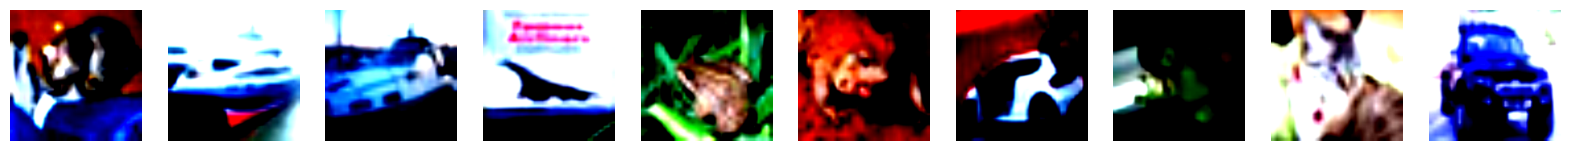

In [12]:
fig, axs = plt.subplots(1,10, figsize=(20, 2))
for i in range(10):
  data, label = test_set[i]
  axs[i].imshow(data.permute((1,2,0)))
  axs[i].axis('off')

In [13]:
train_loader = DataLoader(train_set,
                          batch_size=args['batch_size'],
                          shuffle=True)

test_loader = DataLoader(test_set,
                          batch_size=args['batch_size'],
                          shuffle=True)

## Adaptando a rede

Vamos escolher um modelo da biblioteca de modelos pré-treinados do PyTorch:<br>
https://pytorch.org/docs/stable/torchvision/models.html

Infelizmente o PyTorch não inclui um modelo pré-treinado da LeNet que implementamos anteriormente. Usaremos então um dos modelos modernos de CNN.

In [14]:
net = models.vgg16_bn(pretrained=True).to(args['device'])
print(net)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:05<00:00, 98.1MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Podemos redefinir a rede com todos os módulos originais **exceto o último**, responsável pela classificação das características aprendidas pelas camadas anteriores.

In [15]:
net.classifier = nn.Sequential(list(net.children())[-1][:-3]).to(args['device'])
print(net)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

## Extraindo

Nesse passo realizamos o mesmo fluxo da função de validação que implementamos anteriormente. Dessa vez não precisamos calcular a predição final, apenas armazenar as saídas da rede.

In [16]:
def extrai_caracteristicas(net, loader):

  # Evaluation mode
  net.eval()

  feat_list, rotulo_list = [], []
  with torch.no_grad():
    for k, batch in enumerate(loader):
      print('\r--{0}/{1}--'.format(k, len(loader)), end='', flush=True)

      dado, rotulo = batch

      # Cast do dado na GPU
      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Extração
      caracteristica = net(dado)
      feat_list.append(caracteristica.detach().cpu().numpy())
      rotulo_list.append(rotulo.detach().cpu().numpy())

  feat_list    = np.asarray(feat_list)
  feat_list    = np.reshape(feat_list, (feat_list.shape[0]*feat_list.shape[1], feat_list.shape[2]))

  rotulo_list  = np.asarray(rotulo_list).ravel()

  return feat_list, rotulo_list


In [17]:
print('Load train')
train_X, train_Y = extrai_caracteristicas(net, train_loader)
print('\nLoad test')
test_X,  test_Y  = extrai_caracteristicas(net, test_loader)

Load train
--2499/2500--
Load test
--499/500--

### Treinando um modelo de classificação (SVM)
Documentação: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

Modelos de classificação no pacote ```scikit-learn``` seguem o seguinte padrão de uso:
```python
# Definição do classificador
clf = LinearSVC()
#Treinando
clf.fit(X, y)
# Usando no teste
pred = clf.predict(Xt)
```

In [ ]:
from sklearn.svm import LinearSVC

clf = LinearSVC()
clf.fit(train_X, train_Y)

pred = clf.predict(test_X)
print('{:.2f}%'.format(accuracy_score(test_Y, pred)*100))



---


# Fine-Tuning

O objetivo aqui é aproveitar o valor de um modelo bem treinado e sua capacidade de generalizar pra dados que nunca viu antes.

Lembre-se que o aprendizado é hierárquico, ou seja, camadas iniciais (em vermelho na imagem) aprendem características de baixo nível (bordas, quinas, etc.) que podem ser aproveitadas para múltiplos datasets. **Adaptamos então camadas mais semânticas** (em amarelo na imagem), que aprendem características mais específicas do dataset de treino.

Aqui seguiremos dois passos:
* Substituir a camada de classificação da rede original;
* "Congelar" camadas iniciais da rede, para preservar seus pesos;
* Definir múltiplas taxas de aprendizado para treinar as camadas finais.

<img src="https://drive.google.com/uc?export=view&id=1BHzTprOsXunB7xmKZ7amcScfh2MRSqO1" alt="drawing" width="400"/>

In [ ]:
net = models.vgg16_bn(pretrained=True).to(args['device'])
print(net)

Dessa vez vamos redefinir a camada de classificação, criando uma nova camada de dimensões adequadas ao nosso desafio.

* O modelo original classificava as 1.000 classes do ImageNet <br>
```nn.Linear(in_features, 1000)```
* Nossa adaptação irá classificar 10 classes do CIFAR10 <br>
```nn.Linear(in_features, 10)```

In [ ]:
in_features = list(net.children())[-1][-1].in_features

new_classifier =list(net.classifier.children())[:-1]
new_classifier.append(nn.Linear(in_features, 10))

net.classifier = nn.Sequential(*new_classifier).to(args['device'])
print(net.classifier)

## Definindo múltiplas taxas de aprendizado

Para "congelar" as camadas iniciais basta alterar o atributo ```requires_grad```, definindo-o como ```False``` para parâmetros que não queremos treinar. Podemos iterar nos parâmetros da rede através da função ```net.named_parameters()```.

Para definir múltiplas taxas de aprendizados no otimizador, podemos consultar a documentação do pacote ```optim```:<br>
https://pytorch.org/docs/stable/optim.html

Podemos definir uma lista de dicionários para cada módulo que desejamos treinar.
```python
optim.Adam([
            {'params': model.base.parameters()},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
          ], lr=0)
```

In [ ]:
optimizer = optim.Adam([
            {'params': net.features.parameters(), 'lr':args['lr']*0.2, 'weight_decay': args['weight_decay']*0.2},
            {'params': net.classifier.parameters(), 'lr': args['lr'], 'weight_decay': args['weight_decay']}
        ], lr=0)

In [ ]:
criterion = nn.CrossEntropyLoss().to(args['device'])

In [ ]:
def train(train_loader, net, epoch):

  # Training mode
  net.train()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  for k, batch in enumerate(train_loader):
    print('\r--{0}/{1}--'.format(k, len(train_loader)), end='', flush=True)
    dado, rotulo = batch

    # Cast do dado na GPU
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    # Forward
    ypred = net(dado)
    # print(ypred.size(), rotulo.size())
    loss = criterion(ypred, rotulo)
    # print(loss.size())
    epoch_loss.append(loss.cpu().data)

    _, pred = torch.max(ypred, axis=1)
    pred_list.append(pred.cpu().numpy())
    rotulo_list.append(rotulo.cpu().numpy())

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('\n#################### Train ####################')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


In [ ]:
def validate(test_loader, net, epoch):

  # Evaluation mode
  net.eval()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  with torch.no_grad():
    for k, batch in enumerate(test_loader):

      print('\r--{0}/{1}--'.format(k, len(test_loader)), end='', flush=True)
      dado, rotulo = batch

      # Cast do dado na GPU
      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      ypred = net(dado)
      loss = criterion(ypred, rotulo)
      epoch_loss.append(loss.cpu().data)

      _, pred = torch.max(ypred, axis=1)
      pred_list.append(pred.cpu().numpy())
      rotulo_list.append(rotulo.cpu().numpy())

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('\n********** Validate **********')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f\n' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


In [ ]:
train_losses, test_losses = [], []
for epoch in range(args['epoch_num']):

  # Train
  train_losses.append(train(train_loader, net, epoch))

  # Validate
  test_losses.append(validate(test_loader, net, epoch))